# Notebook 03 — Model A: TF-IDF + Linear Baseline
**Week 2**: One-vs-rest Logistic Regression / LinearSVC trained on TF-IDF features with per-label threshold tuning.

In [1]:
pip install -q scikit-learn pandas pyarrow numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Running locally — no Drive mount needed

## 1. Config

In [3]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import pickle, os, json
from pathlib import Path

DATA_DIR  = '../datasets/processed'
MODEL_DIR = '../data/models/model_a'
os.makedirs(MODEL_DIR, exist_ok=True)

CLASSIFIER     = 'sgd'      # 'sgd' (fastest) | 'lr' | 'svm'
C_REG          = 1.0
MAX_ITER       = 100         # SGD converges much faster than saga
N_JOBS         = -1

## 2. Load features & labels

In [4]:
X_train = sp.load_npz(f'{DATA_DIR}/X_train_tfidf.npz')
X_val   = sp.load_npz(f'{DATA_DIR}/X_val_tfidf.npz')
X_test  = sp.load_npz(f'{DATA_DIR}/X_test_tfidf.npz')
Y_train = np.load(f'{DATA_DIR}/Y_train.npy')
Y_val   = np.load(f'{DATA_DIR}/Y_val.npy')
Y_test  = np.load(f'{DATA_DIR}/Y_test.npy')

with open(f'{DATA_DIR}/mlb.pkl', 'rb') as f:
    mlb = pickle.load(f)
vocab = list(mlb.classes_)

print(f'X_train: {X_train.shape}  Y_train: {Y_train.shape}')
print(f'Labels: {len(vocab)}')

X_train: (85081, 50000)  Y_train: (85081, 50)
Labels: 50


## 3. Train One-vs-Rest classifier

In [5]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC

if CLASSIFIER == 'sgd':
    base = SGDClassifier(
        loss='log_loss',
        penalty='l2',
        alpha=1.0 / (C_REG * X_train.shape[0]),
        max_iter=MAX_ITER,
        class_weight='balanced',
        tol=1e-3,
        random_state=42,
    )
    clf = OneVsRestClassifier(base, n_jobs=N_JOBS)
elif CLASSIFIER == 'lr':
    base = LogisticRegression(C=C_REG, max_iter=MAX_ITER, solver='liblinear',
                              class_weight='balanced')
    clf = OneVsRestClassifier(base, n_jobs=N_JOBS)
else:  # svm
    base = LinearSVC(C=C_REG, max_iter=MAX_ITER, class_weight='balanced')
    clf = OneVsRestClassifier(base, n_jobs=N_JOBS)

print(f'Training OvR on {X_train.shape[0]} samples × {len(vocab)} labels...')
clf.fit(X_train, Y_train)
print('Done.')

with open(f'{MODEL_DIR}/clf_{CLASSIFIER}.pkl', 'wb') as f:
    pickle.dump(clf, f)
print('Model saved.')

Training OvR on 85081 samples × 50 labels...
Done.
Model saved.


## 4. Probability estimates

In [6]:
print('Computing probabilities on val set...')
if hasattr(clf, 'predict_proba'):
    P_val  = clf.predict_proba(X_val)
    P_test = clf.predict_proba(X_test)
else:
    # LinearSVC: use decision_function + sigmoid for pseudo-probabilities
    from scipy.special import expit
    P_val  = expit(clf.decision_function(X_val))
    P_test = expit(clf.decision_function(X_test))
print(f'P_val shape: {P_val.shape}')

Computing probabilities on val set...
P_val shape: (18371, 50)


## 5. Threshold tuning on validation set

In [7]:
from sklearn.metrics import f1_score

def tune_global_threshold(P, Y, thresholds=np.arange(0.05, 0.55, 0.025)):
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = (P >= t).astype(int)
        f1 = f1_score(Y, preds, average='micro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

best_t, best_f1_val = tune_global_threshold(P_val, Y_val)
print(f'Best global threshold: {best_t:.3f}  →  micro-F1 on val: {best_f1_val:.4f}')

Best global threshold: 0.525  →  micro-F1 on val: 0.5963


## 6. Evaluation

In [8]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score
)

def evaluate(P, Y, threshold, split_name='test'):
    preds = (P >= threshold).astype(int)
    results = {
        'split'       : split_name,
        'threshold'   : threshold,
        'micro_f1'    : f1_score(Y, preds, average='micro',   zero_division=0),
        'macro_f1'    : f1_score(Y, preds, average='macro',   zero_division=0),
        'micro_prec'  : precision_score(Y, preds, average='micro', zero_division=0),
        'micro_rec'   : recall_score(Y, preds, average='micro',    zero_division=0),
    }
    # AUPRC / AUROC — only for labels with positives in this split
    mask = Y.sum(0) > 0
    results['macro_auprc'] = average_precision_score(Y[:, mask], P[:, mask], average='macro')
    results['micro_auroc'] = roc_auc_score(Y[:, mask], P[:, mask], average='micro')
    for k, v in results.items():
        if isinstance(v, float):
            print(f'  {k:20s}: {v:.4f}')
        else:
            print(f'  {k:20s}: {v}')
    return results

print('=== Validation ===')
val_results  = evaluate(P_val,  Y_val,  best_t, 'val')
print('\n=== Test ===')
test_results = evaluate(P_test, Y_test, best_t, 'test')

with open(f'{MODEL_DIR}/results.json', 'w') as f:
    json.dump({'val': val_results, 'test': test_results}, f, indent=2)
print('\nResults saved.')

=== Validation ===
  split               : val
  threshold           : 0.5250
  micro_f1            : 0.5963
  macro_f1            : 0.5682
  micro_prec          : 0.4951
  micro_rec           : 0.7496
  macro_auprc         : 0.5757
  micro_auroc         : 0.9267

=== Test ===
  split               : test
  threshold           : 0.5250
  micro_f1            : 0.5952
  macro_f1            : 0.5696
  micro_prec          : 0.4941
  micro_rec           : 0.7483
  macro_auprc         : 0.5741
  micro_auroc         : 0.9250

Results saved.


## 7. Head vs. tail label analysis

head (≥500)                n_codes=   50  avg_F1=0.5696
torso (100-499)            n_codes=    0  avg_F1=nan
tail (<100)                n_codes=    0  avg_F1=nan


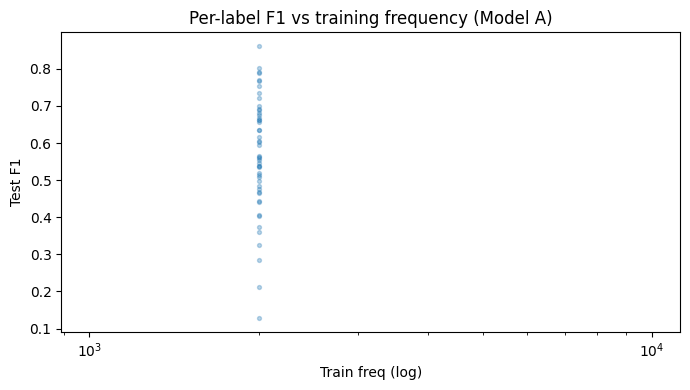

In [9]:
import matplotlib.pyplot as plt

# Per-label F1 on test set
preds_test = (P_test >= best_t).astype(int)
per_label_f1   = f1_score(Y_test, preds_test, average=None, zero_division=0)
per_label_freq = Y_train.sum(0)   # training frequency

label_df = pd.DataFrame({
    'icd_code'   : vocab,
    'train_freq' : per_label_freq,
    'test_f1'    : per_label_f1
}).sort_values('train_freq', ascending=False)

# Bucket labels into head / torso / tail
thresholds_freq = [500, 100, 0]
labels_bucket   = ['head (≥500)', 'torso (100-499)', 'tail (<100)']

for bucket, (lo, hi) in zip(labels_bucket, [(500, 1e9), (100, 499), (0, 99)]):
    subset = label_df[(label_df['train_freq'] >= lo) & (label_df['train_freq'] <= hi)]
    print(f'{bucket:25s}  n_codes={len(subset):5d}  avg_F1={subset["test_f1"].mean():.4f}')

# Scatter: frequency vs F1
plt.figure(figsize=(7, 4))
plt.scatter(label_df['train_freq'].clip(upper=2000), label_df['test_f1'], alpha=0.3, s=8)
plt.xscale('log'); plt.xlabel('Train freq (log)'); plt.ylabel('Test F1')
plt.title('Per-label F1 vs training frequency (Model A)')
plt.tight_layout(); plt.savefig(f'{MODEL_DIR}/head_tail_f1.png', dpi=120); plt.show()

## 8. Top-K evaluation (Top-50, Top-100, Top-500)

In [10]:
for K in [50, 100, 500]:
    top_k_idx = label_df.nlargest(K, 'train_freq').index
    Y_k = Y_test[:, top_k_idx]
    P_k = P_test[:, top_k_idx]
    preds_k = (P_k >= best_t).astype(int)
    mf1 = f1_score(Y_k, preds_k, average='micro', zero_division=0)
    print(f'Top-{K:4d}  micro-F1 = {mf1:.4f}')

Top-  50  micro-F1 = 0.5952
Top- 100  micro-F1 = 0.5952
Top- 500  micro-F1 = 0.5952


## 9. Confusion Matrix (Per-Label)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle, json, os
import scipy.sparse as sp
from sklearn.metrics import multilabel_confusion_matrix

DATA_DIR  = '../datasets/processed'
MODEL_DIR = '../data/models/model_a'
TOP_N = 10

with open(f'{DATA_DIR}/mlb.pkl', 'rb') as f:
    mlb = pickle.load(f)
vocab = list(mlb.classes_)

Y_test  = np.load(f'{DATA_DIR}/Y_test.npy')
Y_train = np.load(f'{DATA_DIR}/Y_train.npy')

X_test_tfidf = sp.load_npz(f'{DATA_DIR}/X_test_tfidf.npz')
with open(f'{MODEL_DIR}/clf_sgd.pkl', 'rb') as f:
    clf = pickle.load(f)
P_test = clf.predict_proba(X_test_tfidf)

with open(f'{MODEL_DIR}/results.json') as f:
    threshold = json.load(f)['test']['threshold']
preds_test = (P_test >= threshold).astype(int)

mcm = multilabel_confusion_matrix(Y_test, preds_test)

freq = Y_train.sum(0)
top_idx = np.argsort(freq)[::-1][:TOP_N]

nrows, ncols = 2, TOP_N // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))

for idx, ax in zip(top_idx, axes.flat):
    cm = mcm[idx]
    ax.imshow(cm, cmap='Blues')
    ax.set_title(vocab[idx], fontsize=10, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Neg', 'Pos']); ax.set_yticklabels(['Neg', 'Pos'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for r in range(2):
        for c in range(2):
            color = 'white' if cm[r, c] > cm.max() / 2 else 'black'
            ax.text(c, r, f'{cm[r, c]:,}', ha='center', va='center', color=color, fontsize=11)

plt.suptitle(f'Per-Label Confusion Matrices — Model A (TF-IDF + SGD), Top {TOP_N} Labels', fontsize=14)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/confusion_matrix_top{TOP_N}.png', dpi=150)
plt.show()

agg = mcm.sum(axis=0)
print(f'\nAggregate Confusion Matrix (all {len(vocab)} labels):')
print(f'  TN = {agg[0,0]:>10,}   FP = {agg[0,1]:>10,}')
print(f'  FN = {agg[1,0]:>10,}   TP = {agg[1,1]:>10,}')

## 10. Full 50-Label Confusion Analysis
For each pair of labels (i, j): when label i is truly present in a sample, how often does the model **falsely** predict label j on that same sample? This reveals which ICD codes the model confuses with each other.

In [ ]:
TOP_PAIRS = 20
n_labels = len(vocab)

fp_mask = (preds_test == 1) & (Y_test == 0)
tp_mask = (Y_test == 1)

label_confusion = tp_mask.astype(int).T @ fp_mask.astype(int)

fig, ax = plt.subplots(figsize=(18, 15))
im = ax.imshow(label_confusion, cmap='Reds', aspect='auto', interpolation='nearest')
ax.set_xticks(range(n_labels)); ax.set_yticks(range(n_labels))
ax.set_xticklabels(vocab, rotation=90, fontsize=7)
ax.set_yticklabels(vocab, fontsize=7)
ax.set_xlabel('Falsely Predicted Label (FP)', fontsize=12)
ax.set_ylabel('Truly Present Label (TP)', fontsize=12)
ax.set_title(f'Model A — {n_labels}-Label Confusion Heatmap', fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.8, label='Count')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/label_confusion_{n_labels}x{n_labels}.png', dpi=150)
plt.show()

np.fill_diagonal(label_confusion, 0)
flat_idx = np.argsort(label_confusion.ravel())[::-1]

print(f'\nTop {TOP_PAIRS} most confused label pairs (Model A):')
print(f'  {"True Label":>12s}  →  {"Falsely Predicted":>18s}  {"Count":>7s}')
print('  ' + '-' * 50)
shown = 0
for fi in flat_idx:
    if shown >= TOP_PAIRS:
        break
    i, j = divmod(fi, n_labels)
    count = label_confusion[i, j]
    if count == 0:
        break
    tp_total = tp_mask[:, i].sum()
    pct = count / tp_total * 100 if tp_total > 0 else 0
    print(f'  {vocab[i]:>12s}  →  {vocab[j]:>18s}  {count:>7,}  ({pct:.1f}% of {vocab[i]} samples)')
    shown += 1